# Pragmatic naming experiment comparison

The accuracy of Naming Understandability Scores assigned by the pragmatic evaluator is compared across models and between GPT-5.6 Luna runs with and without the Context Description.

In [63]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from pymongo import MongoClient

# The project directory is added so src can be imported from Jupyter.
sys.path.insert(0, str(next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "src/config.py").is_file()
)))
from src.config import BASE_URL

EXPERIMENTS = {
    "pragmatic-context-gpt5-6-luna": "GPT-5.6 Luna (with context)",
    "pragmatic-no-context-gpt5-6-luna": "GPT-5.6 Luna (without context)",
    "glm-5-3-flash-naming-context": "GLM-5.3 Flash",
    "qwen3-8-flash-naming-context": "Qwen3-8 Flash",
    "gemini-3-5-flash-lite-naming-context": "Gemini 3.5 Flash Lite",
}
MODEL_COLORS = {
    "GPT-5.6 Luna (with context)": "#1f77b4",
    "GPT-5.6 Luna (without context)": "#17becf",
    "GLM-5.3 Flash": "#ff7f0e",
    "Qwen3-8 Flash": "#9467bd",
    "Gemini 3.5 Flash Lite": "#d62728",
}
COLLECTION_NAME = "pragmatic_naming_eval"
MONGODB_URI = os.getenv(
    "MONGODB_URI",
    "mongodb://127.0.0.1:27017/llm_uml_evaluator?replicaSet=rs0",
)

FIGURES_DIR = BASE_URL / "eval/figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")

## Data loading

The URI is read from the `MONGODB_URI` environment variable. JupyterLab is started with `uv run --env-file .env --group eval jupyter lab`.

In [64]:
client = MongoClient(MONGODB_URI, serverSelectionTimeoutMS=5_000)
try:
    collection = client.get_default_database()[COLLECTION_NAME]
    documents = list(
        collection.find(
            {"experiment_name": {"$in": list(EXPERIMENTS)}},
            {
                "experiment_name": 1,
                "sample": 1,
                "mutation": 1,
                "nodes": 1,
            },
        )
    )
finally:
    client.close()

loaded_experiments = {document["experiment_name"] for document in documents}
if missing := set(EXPERIMENTS).difference(loaded_experiments):
    raise ValueError(f"No observations found for: {sorted(missing)}")

pd.Series(
    (document["experiment_name"] for document in documents),
    name="experiment_name",
).value_counts().rename("observations")

experiment_name
pragmatic-context-gpt5-6-luna           120
pragmatic-no-context-gpt5-6-luna        120
qwen3-8-flash-naming-context            120
gemini-3-5-flash-lite-naming-context    120
glm-5-3-flash-naming-context            120
Name: observations, dtype: int64

## Metric calculation

One expected score and one returned score are assigned to each evaluated node. A correct node-score pair is counted as TP. An incorrect score is counted once as FP (the returned pair) and once as FN (the missing expected pair). Consequently, FP = FN and precision, recall, F1, and node accuracy are equal under this output contract.

Node accuracy is used for simpler interpretation:

```text
Node accuracy = TP / (TP + FN)
              = correctly scored nodes / evaluated nodes
```

The equality FP = FN is checked before this simplification is applied. An observation with no evaluated nodes is assigned an undefined accuracy and excluded from the mean. All nodes correct rate is calculated separately as the proportion of observations with no scoring errors.


In [65]:
df = pd.json_normalize(documents).rename(
    columns={
        "nodes.true_positive": "tp",
        "nodes.false_positive": "fp",
        "nodes.false_negative": "fn",
    }
)

required_columns = {
    "experiment_name", "sample", "mutation", "tp", "fp", "fn"
}
if missing := required_columns.difference(df.columns):
    raise ValueError(f"Missing columns: {sorted(missing)}")

if not df["fp"].eq(df["fn"]).all():
    raise ValueError("Expected FP = FN for one returned score per evaluated node")

df["model"] = df["experiment_name"].map(EXPERIMENTS)
evaluated_nodes = df["tp"] + df["fn"]
df["node_accuracy"] = df["tp"] / evaluated_nodes.where(evaluated_nodes.ne(0))
df["all_nodes_correct"] = df["fp"].eq(0) & df["fn"].eq(0)

df[
    [
        "experiment_name",
        "sample",
        "mutation",
        "model",
        "node_accuracy",
        "all_nodes_correct",
    ]
].head()

,experiment_name,sample,mutation,model,node_accuracy,all_nodes_correct
0,pragmatic-context-gpt5-6-luna,1,0,GPT-5.6 Luna (with context),1.0,True
1,pragmatic-context-gpt5-6-luna,1,0,GPT-5.6 Luna (with context),1.0,True
2,pragmatic-context-gpt5-6-luna,1,0,GPT-5.6 Luna (with context),1.0,True
3,pragmatic-context-gpt5-6-luna,1,1,GPT-5.6 Luna (with context),1.0,True
4,pragmatic-context-gpt5-6-luna,1,1,GPT-5.6 Luna (with context),1.0,True


## Coverage check

The table shows the number of repetitions for each `model × sample × mutation` combination.

In [66]:
coverage = (
    df.groupby(["model", "sample", "mutation"], sort=False)
    .size()
    .unstack(fill_value=0)
)
display(coverage)
display(
    df.groupby(["model", "mutation"], sort=False)["node_accuracy"]
    .agg(["mean", "std", "count"])
    .round(3)
)

mutation                               0  1  2  3
model                          sample            
GPT-5.6 Luna (with context)    1       3  3  3  3
                               2       3  3  3  3
                               3       3  3  3  3
                               4       3  3  3  3
                               5       3  3  3  3
                               6       3  3  3  3
                               7       3  3  3  3
                               8       3  3  3  3
                               9       3  3  3  3
                               10      3  3  3  3
GPT-5.6 Luna (without context) 1       3  3  3  3
                               2       3  3  3  3
                               3       3  3  3  3
                               4       3  3  3  3
                               5       3  3  3  3
                               6       3  3  3  3
                               7       3  3  3  3
                               8       3  3  3  3
                               9       3  3  3  3
                               10      3  3  3  3
Qwen3-8 Flash                  1       3  3  3  3
                               2       3  3  3  3
                               3       3  3  3  3
                               4       3  3  3  3
                               5       3  3  3  3
                               6       3  3  3  3
                               7       3  3  3  3
                               8       3  3  3  3
                               9       3  3  3  3
                               10      3  3  3  3
Gemini 3.5 Flash Lite          1       3  3  3  3
                               2       3  3  3  3
                               3       3  3  3  3
                               4       3  3  3  3
                               5       3  3  3  3
                               6       3  3  3  3
                               7       3  3  3  3
                               8       3  3  3  3
                               9       3  3  3  3
                               10      3  3  3  3
GLM-5.3 Flash                  1       3  3  3  3
                               2       3  3  3  3
                               3       3  3  3  3
                               4       3  3  3  3
                               5       3  3  3  3
                               6       3  3  3  3
                               7       3  3  3  3
                               8       3  3  3  3
                               9       3  3  3  3
                               10      3  3  3  3

mean    std  count
model                          mutation                     
GPT-5.6 Luna (with context)    0         0.995  0.015     30
                               1         0.996  0.016     30
                               2         0.991  0.025     30
                               3         0.993  0.025     30
GPT-5.6 Luna (without context) 0         0.851  0.103     30
                               1         0.959  0.047     30
                               2         0.937  0.063     30
                               3         0.938  0.072     30
Qwen3-8 Flash                  0         0.965  0.059     30
                               1         0.964  0.063     30
                               2         0.943  0.071     30
                               3         0.948  0.069     30
Gemini 3.5 Flash Lite          0         0.998  0.011     30
                               1         0.998  0.011     30
                               2         0.967  0.050     30
                               3         0.984  0.029     30
GLM-5.3 Flash                  0         0.968  0.068     30
                               1         0.978  0.058     30
                               2         0.977  0.034     30
                               3         0.983  0.047     30

## Model comparison by mutation

Mean node accuracy and the rate of observations with all nodes correct are shown for every model.

In [67]:
node_accuracy_comparison = (
    df.groupby(["mutation", "model"], sort=False)["node_accuracy"]
    .mean()
    .unstack()
    .reindex(columns=EXPERIMENTS.values())
)
all_correct_comparison = (
    df.groupby(["mutation", "model"], sort=False)["all_nodes_correct"]
    .mean()
    .unstack()
    .reindex(columns=EXPERIMENTS.values())
)
comparison = pd.concat(
    {"Node accuracy": node_accuracy_comparison, "All nodes correct rate": all_correct_comparison},
    axis=1,
)
comparison.style.format(
    {
        ("Node accuracy", column): "{:.3f}"
        for column in EXPERIMENTS.values()
    }
    | {
        ("All nodes correct rate", column): "{:.1%}"
        for column in EXPERIMENTS.values()
    }
)

## Node accuracy by mutation

Mean node accuracy is shown for each model and mutation. Each observation is given equal weight; node counts are not pooled across diagrams. The minimum and maximum observation accuracies across samples and repetitions are represented by the error bars, not confidence intervals.


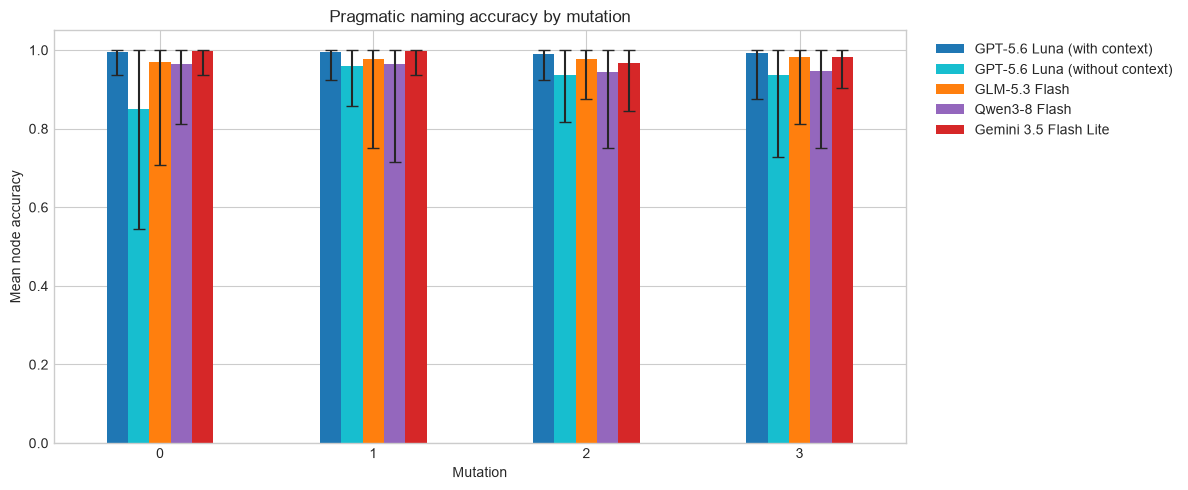

In [68]:
node_accuracy_by_mutation = df.groupby(["model", "mutation"], sort=False)["node_accuracy"].agg(
    ["mean", "min", "max"]
)
ylim = (0, 1.05)

node_accuracy_means = (
    node_accuracy_by_mutation["mean"]
    .unstack("model")
    .reindex(columns=EXPERIMENTS.values())
)
node_accuracy_mins = (
    node_accuracy_by_mutation["min"]
    .unstack("model")
    .reindex(columns=EXPERIMENTS.values())
)
node_accuracy_maxs = (
    node_accuracy_by_mutation["max"]
    .unstack("model")
    .reindex(columns=EXPERIMENTS.values())
)
errors = {
    model: [
        (node_accuracy_means[model] - node_accuracy_mins[model]).to_numpy(),
        (node_accuracy_maxs[model] - node_accuracy_means[model]).to_numpy(),
    ]
    for model in node_accuracy_means
}
fig, ax = plt.subplots(figsize=(12, 5))
node_accuracy_means.plot.bar(
    ax=ax,
    yerr=errors,
    capsize=4,
    rot=0,
    color=[MODEL_COLORS[model] for model in node_accuracy_means],
)
ax.set(
    title="Pragmatic naming accuracy by mutation",
    xlabel="Mutation",
    ylabel="Mean node accuracy",
    ylim=ylim,
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

### Save figure

In [69]:
fig.savefig(
    FIGURES_DIR / "pragmatic_node_accuracy_by_mutation.png",
    dpi=300,
    bbox_inches="tight",
)

## All nodes correct rate

An observation is counted as correct only when every evaluated node is assigned the expected Naming Understandability Score.

The number of completely correct observations (`correct`), the total number of observations (`evaluated`), and their ratio (`exact_case_rate`) are reported for each mutation and model. Repeated runs are included in these counts; they are not treated as additional independent diagrams.

,,correct,evaluated,exact_case_rate
mutation,model,,,
0,GPT-5.6 Luna (with context),27,30,90.0%
1,GPT-5.6 Luna (with context),28,30,93.3%
2,GPT-5.6 Luna (with context),26,30,86.7%
3,GPT-5.6 Luna (with context),27,30,90.0%
0,GPT-5.6 Luna (without context),3,30,10.0%
1,GPT-5.6 Luna (without context),15,30,50.0%
2,GPT-5.6 Luna (without context),12,30,40.0%
3,GPT-5.6 Luna (without context),13,30,43.3%
0,Qwen3-8 Flash,20,30,66.7%


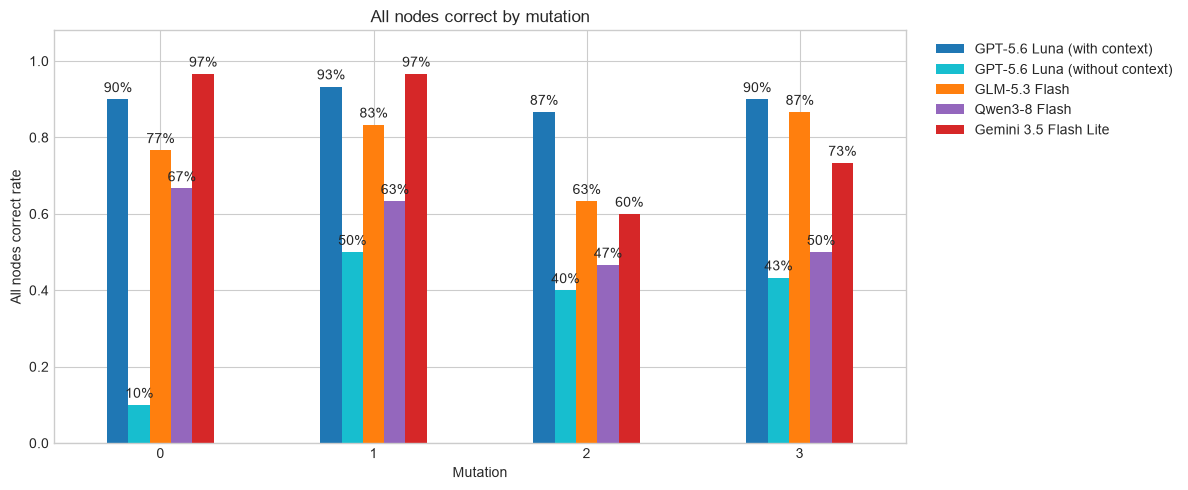

In [70]:
exact_summary = (
    df.groupby(["mutation", "model"], sort=False)["all_nodes_correct"]
    .agg(correct="sum", evaluated="count", exact_case_rate="mean")
)
display(exact_summary.style.format({"exact_case_rate": "{:.1%}"}))

all_correct_by_mutation = (
    exact_summary["exact_case_rate"]
    .unstack("model")
    .reindex(columns=EXPERIMENTS.values())
)

fig, ax = plt.subplots(figsize=(12, 5))
all_correct_by_mutation.plot.bar(
    ax=ax,
    rot=0,
    color=[MODEL_COLORS[model] for model in all_correct_by_mutation],
)
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{value:.0%}" for value in container.datavalues],
        padding=3,
    )
ax.set(
    title="All nodes correct by mutation",
    xlabel="Mutation",
    ylabel="All nodes correct rate",
    ylim=(0, 1.08),
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

### Save figure

In [71]:
fig.savefig(
    FIGURES_DIR / "pragmatic_all_nodes_correct.png",
    dpi=300,
    bbox_inches="tight",
)